https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

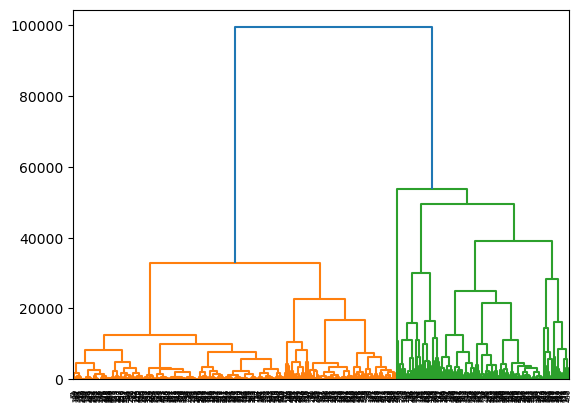

c:\Users\me01\miniconda3\envs\ML_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage,dendrogram

df = pd.read_csv('CC GENERAL.csv')
df.drop(columns=['CUST_ID'], errors='ignore', inplace=True)
df.dropna(inplace=True)
random_rows = df.sample(n=500)

features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

X = random_rows[features].copy()

dendrogram(linkage(X,method="ward"))
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_normalized_sklearn = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

cluster = 3
kmeans = KMeans(n_clusters=cluster, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)




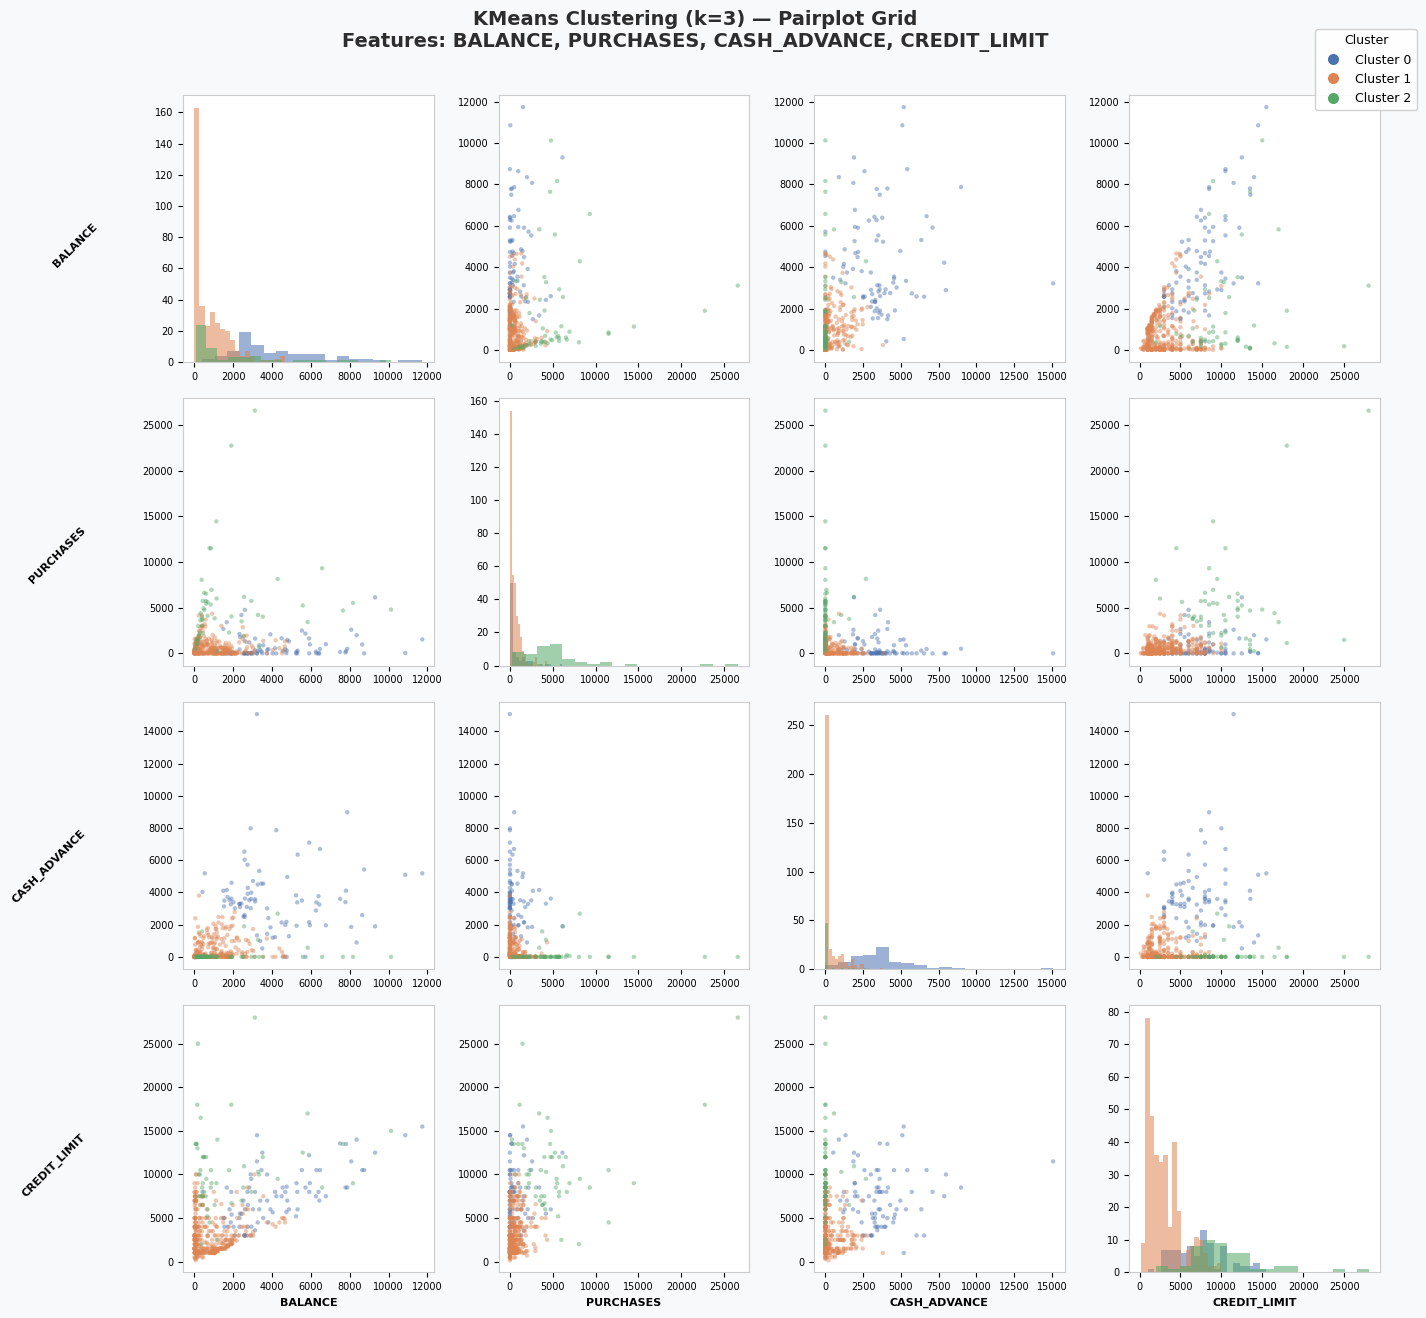

In [33]:
def subplots(): 
    PALETTE  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
    colors   = [PALETTE[i] for i in labels]
    n        = len(features)


    fig, axes = plt.subplots(n, n, figsize=(14, 13), facecolor='#F8F9FA')
    fig.suptitle(f'KMeans Clustering (k={cluster}) — Pairplot Grid\n'
                f'Features: {", ".join(features)}',
                fontsize=14, fontweight='bold', y=1.01, color='#2d2d2d')
    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            ax.set_facecolor('white')
            ax.tick_params(labelsize=7)

            if row == col:
                for k in range(cluster):
                    mask = labels == k
                    ax.hist(X[features[row]].values[mask], bins=18,
                            color=PALETTE[k], alpha=0.55, edgecolor='none')
                ax.set_ylabel(features[row], fontsize=8, fontweight='bold',
                            rotation=45, labelpad=40, ha='right')

            else:
                for k in range(cluster):
                    mask = labels == k
                    ax.scatter(
                        X[features[col]].values[mask],
                        X[features[row]].values[mask],
                        c=PALETTE[k], alpha=0.45, s=10,
                        edgecolors='none', label=f'Cluster {k}'
                    )

            if row == n - 1:
                ax.set_xlabel(features[col], fontsize=8, fontweight='bold')
            else:
                ax.set_xlabel('')
            if col == 0 and row != col:
                ax.set_ylabel(features[row], fontsize=8, fontweight='bold',
                            rotation=45, labelpad=40, ha='right')
            elif col != 0:
                ax.set_ylabel('')

            for spine in ax.spines.values():
                spine.set_edgecolor('#cccccc')


    handles = [plt.Line2D([0], [0], marker='o', color='w',
                        markerfacecolor=PALETTE[k], markersize=9,
                        label=f'Cluster {k}') for k in range(cluster)]
    fig.legend(handles=handles, title='Cluster', title_fontsize=9,
            fontsize=9, loc='upper right', bbox_to_anchor=(1.02, 1.0),
            framealpha=0.9)

    plt.tight_layout()

    plt.show()

subplots()